# Práctica 3. Primeros circuitos cuánticos con Qiskit

**Duración estimada:** 60–75 minutos   
**Herramientas:** Python, NumPy, Qiskit, Qiskit Aer y Matplotlib

> Completa las celdas marcadas con `TODO` y responde razonadamente en las celdas Markdown. Ejecuta al terminar **Kernel → Restart & Run All**.

## Objetivos

- Crear y visualizar circuitos de uno y dos qubits.
- Diferenciar qubits, bits clásicos, puertas y medidas.
- Preparar $|0\rangle$ y $|1\rangle$.
- Obtener amplitudes y probabilidades exactas con `Statevector`.
- Transpilar y ejecutar circuitos con `AerSimulator`.
- Obtener conteos, frecuencias e histogramas.
- Distinguir simulación exacta y muestreo.
- Interpretar el orden de bits de Qiskit.
- Comparar Qiskit con el formalismo matricial de NumPy.

## Entrega

Entrega este notebook con el nombre:

```text
04_primeros_circuitos_qiskit_apellidos_nombre.ipynb
```

Debe contener código ejecutado, circuitos dibujados, resultados, respuestas, pruebas y una conclusión final. No se aceptarán respuestas compuestas únicamente por código.

# Preparación del entorno

## Ejercicio 1. Instalación y comprobación

Si el entorno no dispone de las bibliotecas, descomenta y ejecuta la siguiente celda una sola vez. Reinicia después el kernel.

In [1]:
# %pip install qiskit qiskit-aer matplotlib pylatexenc

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from numbers import Integral

import qiskit
import qiskit_aer

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit.circuit.library import HGate, XGate
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

def applyStyle():
    plt.style.use("default")

    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "serif"]
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["axes.titlesize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["legend.fontsize"] = 10

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True
    plt.rcParams["xtick.minor.visible"] = True
    plt.rcParams["ytick.minor.visible"] = True

    plt.rcParams["lines.linewidth"] = 1.0
    plt.rcParams["lines.markersize"] = 3

    plt.rcParams["legend.frameon"] = True
    plt.rcParams["legend.edgecolor"] = "black"
    plt.rcParams["legend.fancybox"] = False

COLOR_TARGET = "#5d54a4"  # Blue violet
COLOR_PRED = "#9154a4"    # Purple
COLOR_ERR = "#404040"     # Dark gray

SEED = 42
np.set_printoptions(precision=5, suppress=True)

applyStyle()


def probsDict(state, decimals=5):
    # probabilities_dict() with plain str/float values, easier to read
    return {str(k): round(float(v), decimals) for k, v in state.probabilities_dict().items()}


print(f"Qiskit:     {qiskit.__version__}")
print(f"Qiskit Aer: {qiskit_aer.__version__}")
print(f"NumPy:      {np.__version__}")

Qiskit:     2.5.2
Qiskit Aer: 0.17.2
NumPy:      2.4.6


### Responde

1. ¿Qué funciones aporta Qiskit?
2. ¿Para qué se utiliza Qiskit Aer?
3. ¿Por qué puede ser necesario reiniciar el kernel después de instalar?
4. ¿Qué biblioteca permite comparar los circuitos con matrices?

**Respuesta:**

1. Qiskit sirve para construir circuitos cuánticos (qubits, bits clásicos, puertas y medidas) y dibujarlos. También trae `quantum_info`, con `Statevector` y `Operator` para calcular estados y operadores exactos, y `transpile` para adaptar un circuito a un backend.

2. Aer es el simulador. Con `AerSimulator` ejecutamos los circuitos en el propio ordenador repitiéndolos un número de shots, y devuelve conteos igual que un ordenador cuántico real.

3. Porque el kernel ya tiene los módulos cargados en memoria. Si instalas o actualizas un paquete con el kernel en marcha, puede seguir usando la versión vieja o no encontrar la nueva. Al reiniciar se carga todo desde cero.

4. NumPy. Los estados son vectores, las puertas matrices y se aplican con `@`. Luego se compara con Qiskit usando `np.allclose`, como en el ejercicio 10.

# Parte A. Construcción de circuitos

## Ejercicio 2. Circuito vacío de un qubit

Crea un circuito con un qubit, sin bits clásicos ni puertas. Muestra el circuito, el número de qubits y el número de bits clásicos. Visualízalo en texto y con Matplotlib.

circuit0:
  type       = QuantumCircuit
  qubits     = 1
  clbits     = 0
  operations = 0

   
q: 
   


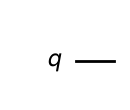

In [3]:
circuit0 = QuantumCircuit(1)

print("circuit0:")
print(f"  type       = {type(circuit0).__name__}")
print(f"  qubits     = {circuit0.num_qubits}")
print(f"  clbits     = {circuit0.num_clbits}")
print(f"  operations = {circuit0.size()}")
print()
print(circuit0.draw())

circuit0.draw("mpl")

### Responde

1. ¿Qué estado tiene inicialmente el qubit?
2. ¿Un circuito vacío carece de estado?
3. ¿Se ha ejecutado al construirlo?
4. ¿Qué diferencia existe entre construir y ejecutar?
5. ¿Qué representa la línea horizontal?

**Respuesta:**

1. |0⟩. En Qiskit todos los qubits empiezan en |0⟩ = (1, 0), y como no hay puertas se queda así.

2. No. Tiene un estado bien definido, el inicial |0⟩. Un circuito vacío es como aplicar la identidad. Se ve en el ejercicio 6, donde `state0` sale `[1, 0]`.

3. No. Solo hemos creado un objeto de Python que describe el circuito. No se ha calculado ni simulado nada, y `operations = 0`.

4. Construir es escribir la receta: qué qubits hay y qué puertas y medidas se aplican. Ejecutar es dársela a un backend (como `AerSimulator`), que la procesa y devuelve resultados. Un circuito se construye una vez y se puede ejecutar muchas veces.

5. Es el qubit `q` a lo largo del tiempo, que avanza de izquierda a derecha. Aquí sale vacía porque no hay ninguna operación.

## Ejercicio 3. Circuito con un bit clásico
Crea un circuito con un qubit y un bit clásico, pero sin medidas. Consulta sus propiedades y visualízalo.

circuitClassical:
  qubits     = 1
  clbits     = 1
  operations = 0

     
  q: 
     
c: 1/
     


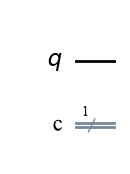

In [4]:
circuitClassical = QuantumCircuit(1, 1)

print("circuitClassical:")
print(f"  qubits     = {circuitClassical.num_qubits}")
print(f"  clbits     = {circuitClassical.num_clbits}")
print(f"  operations = {circuitClassical.size()}")
print()
print(circuitClassical.draw())

circuitClassical.draw("mpl")

### Responde

1. ¿Qué diferencia presenta respecto al circuito anterior?
2. ¿Declarar un bit clásico mide automáticamente?
3. ¿Para qué se utilizará el bit clásico?
4. ¿Puede encontrarse en superposición?

**Respuesta:**

1. Tiene además un bit clásico, así que `clbits` pasa de 0 a 1 y en el dibujo aparece una segunda línea doble, `c`. Por lo demás es igual: sin puertas ni medidas.

2. No. Declarar el bit solo reserva sitio para guardar un resultado, para medir hay que añadir `measure(0, 0)`. Por eso `operations` sigue en 0.

3. Para guardar el resultado de medir el qubit. Con `measure(0, 0)` el 0 o 1 que salga se escribe en ese bit, y con esos valores se construyen los conteos.

4. No. Un bit clásico vale 0 o 1 en cada ejecución, nunca las dos cosas. La superposición es cosa de los qubits.

## Ejercicio 4. Preparación de $|1\rangle$

Crea un circuito de un qubit, aplica $X$ al qubit 0 y visualízalo.

circuit1:
  qubits     = 1
  operations = 1
  gates      = {'x': 1}

x(1) on one qubit -> CircuitError: 'Index 1 out of range for size 1.'

   ┌───┐
q: ┤ X ├
   └───┘


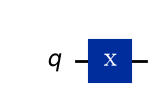

In [5]:
circuit1 = QuantumCircuit(1)
circuit1.x(0)

print("circuit1:")
print(f"  qubits     = {circuit1.num_qubits}")
print(f"  operations = {circuit1.size()}")
print(f"  gates      = {dict(circuit1.count_ops())}")
print()

try:
    QuantumCircuit(1).x(1)  # is there a qubit with index 1?
except Exception as error:
    print(f"x(1) on one qubit -> {type(error).__name__}: {error}")
    print()

print(circuit1.draw())

circuit1.draw("mpl")

### Responde

1. ¿Cuál es el estado inicial?
2. ¿Qué transformación realiza $X$?
3. ¿Qué estado debe obtenerse?
4. ¿Qué indica el argumento de `x(0)`?
5. ¿Qué ocurriría al utilizar `x(1)` en este circuito?

**Respuesta:**

1. |0⟩ = (1, 0), el estado por defecto de Qiskit.

2. X es la puerta NOT cuántica, con matriz ((0, 1), (1, 0)). Intercambia las amplitudes: X|0⟩ = |1⟩ y X|1⟩ = |0⟩. En la esfera de Bloch es un giro de π alrededor del eje X.

3. |1⟩ = (0, 1). Se comprueba en el ejercicio 7.

4. El índice del qubit sobre el que actúa la puerta. Los qubits se numeran desde 0, así que `x(0)` actúa sobre el primero (y único).

5. Da error, porque el qubit 1 no existe. Lo he probado en la celda y sale `CircuitError: 'Index 1 out of range for size 1.'`. Qiskit no crea qubits nuevos, habría que usar `QuantumCircuit(2)`.

## Ejercicio 5. Dos aplicaciones de $X$
Construye y visualiza un circuito con dos puertas $X$ consecutivas sobre el mismo qubit. Predice el estado final antes de simularlo.

circuitXX:
  qubits     = 1
  operations = 2
  depth      = 2
  gates      = {'x': 2}

   ┌───┐┌───┐
q: ┤ X ├┤ X ├
   └───┘└───┘


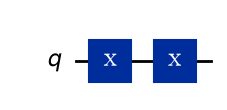

In [6]:
circuitXX = QuantumCircuit(1)
circuitXX.x(0)
circuitXX.x(0)

print("circuitXX:")
print(f"  qubits     = {circuitXX.num_qubits}")
print(f"  operations = {circuitXX.size()}")
print(f"  depth      = {circuitXX.depth()}")
print(f"  gates      = {dict(circuitXX.count_ops())}")
print()
print(circuitXX.draw())

circuitXX.draw("mpl")

### Responde

1. ¿Cuál debe ser el estado final?
2. ¿Qué relación se cumple entre $X^2$ y la identidad?
3. ¿Importa que ambas puertas actúen sobre el mismo qubit?
4. ¿Se aplican simultáneamente?

**Respuesta:**

1. |0⟩. La primera X lleva |0⟩ a |1⟩ y la segunda lo devuelve a |0⟩. Se comprueba en el ejercicio 8.

2. X² = I, es decir, X es su propia inversa y aplicarla dos veces deja cualquier estado igual. Lo compruebo con NumPy en el ejercicio 10 (`X² == I: True`).

3. Sí. Se anulan porque actúan sobre el mismo qubit. Con `x(0)` y `x(1)` en un circuito de dos qubits cada uno se invertiría una sola vez y saldría |11⟩.

4. No. Se aplican una detrás de otra, la segunda sobre lo que deja la primera. Por eso sale `depth = 2`. Dos puertas sobre el mismo qubit nunca pueden ir a la vez.

# Parte B. Vectores de estado

## Ejercicio 6. Estado del circuito vacío

Obtén `Statevector.from_instruction(circuito_0)`. Muestra el objeto, `data`, sus tipos y la forma del array. Compáralo con $|0\rangle=(1,0)^T$.

In [7]:
state0 = Statevector.from_instruction(circuit0)
ket0 = np.array([1, 0], dtype=complex)

print(state0)
print()
print(f"type(state0)      = {type(state0).__name__}")
print(f"state0.data       = {state0.data}")
print(f"type(state0.data) = {type(state0.data).__name__}")
print(f"dtype             = {state0.data.dtype}")
print(f"shape             = {state0.data.shape}")
print(f"dim               = {state0.dim}")
print()
print(f"ket0 (NumPy)      = {ket0}")
print(f"equal             = {np.allclose(state0.data, ket0)}")

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

type(state0)      = Statevector
state0.data       = [1.+0.j 0.+0.j]
type(state0.data) = ndarray
dtype             = complex128
shape             = (2,)
dim               = 2

ket0 (NumPy)      = [1.+0.j 0.+0.j]
equal             = True


### Responde

1. ¿Qué diferencia existe entre `Statevector` y `data`?
2. ¿Cuántas amplitudes contiene un qubit?
3. ¿Por qué son complejas?
4. ¿Por qué se utiliza `np.allclose()`?

**Respuesta:**

1. `Statevector` es el objeto de Qiskit que representa el estado, con métodos como `probabilities()` o `draw()`. `data` es solo el array de NumPy con las amplitudes (sale `ndarray`). Es decir, `data` es el contenido y `Statevector` el objeto que lo envuelve.

2. Dos, una para |0⟩ y otra para |1⟩ (`shape = (2,)`). Con n qubits son 2ⁿ.

3. Porque en general las amplitudes son complejas y ahí va la fase, que es la que produce la interferencia. Aunque aquí salgan 1 y 0, Qiskit siempre usa `complex128` para poder representar cualquier estado.

4. Porque en coma flotante hay pequeños errores de redondeo (1/√2 no se guarda exacto) y `==` podría dar `False` aunque los valores sean iguales. `np.allclose` compara con un margen.

## Ejercicio 7. Estado después de $X$
Obtén el vector de `circuito_1`. Muestra norma, amplitudes y probabilidades. Compáralo con $|1\rangle=(0,1)^T$.

In [8]:
state1 = Statevector.from_instruction(circuit1)
ket1 = np.array([0, 1], dtype=complex)

norm = np.linalg.norm(state1.data)
probs = state1.probabilities()

print(f"state1.data = {state1.data}")
print(f"norm        = {norm:.5f}")
print(f"normalized  = {np.isclose(norm, 1.0)}")
print()
print(f"{'basis':>5} | {'amplitude':>12} | {'probability':>11}")
print("-" * 34)
for index, (amplitude, p) in enumerate(zip(state1.data, probs)):
    print(f"{'|' + str(index) + '>':>5} | {amplitude:>12.3f} | {p:>11.3f}")
print()
print(f"ket1 (NumPy) = {ket1}")
print(f"equal        = {np.allclose(state1.data, ket1)}")

state1.data = [0.+0.j 1.+0.j]
norm        = 1.00000
normalized  = True

basis |    amplitude | probability
----------------------------------
  |0> | 0.000+0.000j |       0.000
  |1> | 1.000+0.000j |       1.000

ket1 (NumPy) = [0.+0.j 1.+0.j]
equal        = True


### Responde

1. ¿Qué amplitud tiene cada estado de la base?
2. ¿Qué probabilidad tiene cada resultado?
3. ¿Se necesitan shots para obtener este vector?
4. ¿Se ha realizado una medida?

**Respuesta:**

1. La de |0⟩ es 0 y la de |1⟩ es 1. El vector es (0, 1), igual que `ket1`, y la norma es 1.

2. P(0) = |0|² = 0 y P(1) = |1|² = 1, como sale en la tabla. Al medir saldría siempre 1.

3. No. `Statevector.from_instruction()` calcula el estado exacto multiplicando matrices, sin simular medidas. No hay shots ni azar, así que sale lo mismo siempre.

4. No. `circuit1` no tiene medidas, las probabilidades de la tabla son teóricas: lo que pasaría si midiéramos. De hecho `Statevector` no acepta circuitos con medidas.

## Ejercicio 8. Estado después de dos $X$
Obtén el estado exacto de `circuito_xx` y comprueba que coincide con $|0\rangle$.

In [9]:
stateXX = Statevector.from_instruction(circuitXX)

print(f"stateXX.data  = {stateXX.data}")
print(f"probabilities = {probsDict(stateXX)}")
print()
print(f"equal to ket0 (NumPy) = {np.allclose(stateXX.data, ket0)}")
print(f"equal to state0       = {stateXX == state0}")
print()
print(f"gates circuit0        = {dict(circuit0.count_ops())}")
print(f"gates circuitXX       = {dict(circuitXX.count_ops())}")
print(f"same circuit          = {circuitXX == circuit0}")
print(f"same operator         = {Operator(circuitXX).equiv(Operator(circuit0))}")
print()
print("Operator(circuitXX) =")
print(Operator(circuitXX).data)

stateXX.data  = [1.+0.j 0.+0.j]
probabilities = {'0': 1.0}

equal to ket0 (NumPy) = True
equal to state0       = True

gates circuit0        = {}
gates circuitXX       = {'x': 2}
same circuit          = False
same operator         = True

Operator(circuitXX) =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


### Responde

1. ¿Ha cambiado el circuito aunque coincida el estado final?
2. ¿Es igual un circuito vacío a otro con dos puertas $X$?
3. ¿Puede deducirse toda la secuencia observando solo el estado final?

**Respuesta:**

1. Sí. `circuitXX` tiene dos puertas y `circuit0` ninguna. Solo coincide el estado final, porque X² = I, pero por el camino el qubit ha pasado por |1⟩.

2. Son equivalentes pero no iguales. Hacen lo mismo (`same operator = True`, el operador sale la identidad), pero son circuitos distintos (`same circuit = False`). En hardware real importa, porque cada puerta tarda y añade ruido.

3. No. Muchos circuitos dan el mismo estado final: vacío, XX, HH o ZZ dejan todos el qubit en |0⟩. El estado final no dice el camino, para eso hay que mirar el circuito.

## Ejercicio 9. Probabilidades exactas

Para los tres estados anteriores, muestra `probabilities()` y `probabilities_dict()` y construye una tabla comparativa.

In [10]:
exactStates = {"empty": state0, "X": state1, "XX": stateXX}

for name, state in exactStates.items():
    print(f"{name}:")
    print(f"  vector               = {state.data}")
    print(f"  probabilities()      = {state.probabilities()}")
    print(f"  probabilities_dict() = {probsDict(state)}")
    print()

print(f"{'circuit':>7} | {'amp |0>':>8} {'amp |1>':>8} | {'P(0)':>5} {'P(1)':>5} | probabilities_dict()")
print("-" * 68)
for name, state in exactStates.items():
    amp0, amp1 = state.data
    p0, p1 = state.probabilities()
    print(f"{name:>7} | {amp0.real:>8.3f} {amp1.real:>8.3f} | {p0:>5.2f} {p1:>5.2f} | {probsDict(state)}")

empty:
  vector               = [1.+0.j 0.+0.j]
  probabilities()      = [1. 0.]
  probabilities_dict() = {'0': 1.0}

X:
  vector               = [0.+0.j 1.+0.j]
  probabilities()      = [0. 1.]
  probabilities_dict() = {'1': 1.0}

XX:
  vector               = [1.+0.j 0.+0.j]
  probabilities()      = [1. 0.]
  probabilities_dict() = {'0': 1.0}

circuit |  amp |0>  amp |1> |  P(0)  P(1) | probabilities_dict()
--------------------------------------------------------------------
  empty |    1.000    0.000 |  1.00  0.00 | {'0': 1.0}
      X |    0.000    1.000 |  0.00  1.00 | {'1': 1.0}
     XX |    1.000    0.000 |  1.00  0.00 | {'0': 1.0}


### Responde

1. ¿Por qué el diccionario puede omitir resultados de probabilidad cero?
2. ¿Son probabilidades exactas o experimentales?
3. ¿Contienen toda la información del estado?
4. ¿Puede reconstruirse la fase solo con ellas?

**Respuesta:**

1. Porque si un resultado no aparece se entiende que su probabilidad es 0, así que no aporta nada. Con n qubits hay 2ⁿ resultados y muchos suelen ser 0. `probabilities()` sí los incluye todos (`[1. 0.]`). Por eso al leer el diccionario conviene usar `get(clave, 0)`.

2. Exactas. Salen de las amplitudes con la regla de Born, sin medir. Las experimentales son las frecuencias que se obtienen con shots.

3. No. Solo guardan |α|² y pierden la fase. Por ejemplo |+⟩ y |−⟩ dan los dos 0.5 y 0.5 pero son estados distintos.

4. No. |α|² es igual para α y para α·e^(iφ), da igual φ. Por ejemplo |1⟩ e i|1⟩ tienen las mismas probabilidades. Para ver la fase relativa hay que medir en otra base.

# Parte C. Comparación con NumPy

## Ejercicio 10. Puerta $X$ matricial

Representa $X$, calcula $X|0\rangle$, $X|1\rangle$ y $X^2|0\rangle$, y compara cada resultado con Qiskit.

In [11]:
xMatrix = np.array([[0, 1], [1, 0]], dtype=complex)

x0 = xMatrix @ ket0             # X|0>
x1 = xMatrix @ ket1             # X|1>
xx0 = xMatrix @ xMatrix @ ket0  # X²|0>

stateX1 = Statevector.from_label("1").evolve(circuit1)  # X|1> with Qiskit

print("xMatrix (NumPy) =")
print(xMatrix)
print("XGate (Qiskit) =")
print(Operator(XGate()).data)
print(f"equal matrices = {np.allclose(xMatrix, Operator(XGate()).data)}")
print()

cases = [
    ("X|0>", x0, state1.data),
    ("X|1>", x1, stateX1.data),
    ("X²|0>", xx0, stateXX.data),
]

for label, numpyResult, qiskitResult in cases:
    print(f"{label}:")
    print(f"  NumPy  = {numpyResult}")
    print(f"  Qiskit = {qiskitResult}")
    print(f"  equal  = {np.allclose(numpyResult, qiskitResult)}")
    print()

print("X² =")
print(xMatrix @ xMatrix)
print(f"X² == I: {np.allclose(xMatrix @ xMatrix, np.eye(2))}")

xMatrix (NumPy) =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
XGate (Qiskit) =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
equal matrices = True

X|0>:
  NumPy  = [0.+0.j 1.+0.j]
  Qiskit = [0.+0.j 1.+0.j]
  equal  = True

X|1>:
  NumPy  = [1.+0.j 0.+0.j]
  Qiskit = [1.+0.j 0.+0.j]
  equal  = True

X²|0>:
  NumPy  = [1.+0.j 0.+0.j]
  Qiskit = [1.+0.j 0.+0.j]
  equal  = True

X² =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
X² == I: True


### Responde

1. ¿Representan NumPy y Qiskit modelos físicos diferentes?
2. ¿Qué elemento de NumPy equivale a una puerta?
3. ¿Qué ventaja proporciona el modelo de circuitos?
4. ¿Por qué sigue siendo útil el formalismo matricial?

**Respuesta:**

1. No. Es el mismo modelo: estados como vectores complejos y puertas como matrices unitarias. Solo cambia el nivel, en NumPy multiplicamos a mano y Qiskit lo hace por dentro. Por eso los tres casos salen `equal = True`.

2. Una matriz unitaria, como `xMatrix`, y aplicarla es el producto `@`. Ojo con el orden: en el circuito se lee de izquierda a derecha, pero con matrices se aplica de derecha a izquierda (A y luego B es B·A|ψ⟩).

3. Que no hay que construir las matrices. Con n qubits son de 2ⁿ × 2ⁿ y se vuelven enormes. Además el circuito se lee mejor, incluye medidas y bits clásicos y se puede ejecutar en un simulador o en hardware real.

4. Porque es la base matemática de lo que hace el circuito. Sirve para entender y comprobar los resultados de Qiskit y para demostrar cosas como X² = I. Con uno o dos qubits es la forma más directa de razonar.

# Parte D. Medida

## Ejercicio 11. Medida de $|0\rangle$

Crea un circuito con un qubit y un bit clásico. Mide el qubit 0 en el bit clásico 0 y visualízalo.

measureCircuit0:
  qubits      = 1
  clbits      = 1
  operations  = {'measure': 1}
  instruction = measure
  is a Gate   = False

     ┌─┐
  q: ┤M├
     └╥┘
c: 1/═╩═
      0 


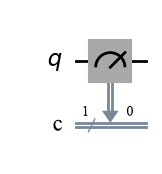

In [12]:
measureCircuit0 = QuantumCircuit(1, 1)
measureCircuit0.measure(0, 0)

instruction = measureCircuit0.data[0].operation

print("measureCircuit0:")
print(f"  qubits      = {measureCircuit0.num_qubits}")
print(f"  clbits      = {measureCircuit0.num_clbits}")
print(f"  operations  = {dict(measureCircuit0.count_ops())}")
print(f"  instruction = {instruction.name}")
print(f"  is a Gate   = {isinstance(instruction, Gate)}")
print()
print(measureCircuit0.draw())

measureCircuit0.draw("mpl")

### Responde

1. ¿Qué significa la flecha de medida?
2. ¿Dónde se almacena el resultado?
3. ¿Cuál debe ser el resultado?
4. ¿La medida es una puerta unitaria?

**Respuesta:**

1. Que se mide el qubit y el resultado se manda al registro clásico. La línea doble baja hasta `c`, y el número indica en qué bit se escribe.

2. En el bit clásico 0, porque `measure(0, 0)` es "mide el qubit 0 y guárdalo en el bit 0".

3. Siempre 0. El qubit está en |0⟩, con P(0) = 1 y P(1) = 0, así que es determinista.

4. No. Las puertas son unitarias y reversibles, la medida colapsa el estado a |0⟩ o |1⟩ y no se puede deshacer (se pierden las amplitudes y la fase). Por eso sale `is a Gate = False`: Qiskit la trata como `Instruction`, no como `Gate`.

## Ejercicio 12. Medida de $|1\rangle$
Construye $|0\rangle\xrightarrow{X}|1\rangle\xrightarrow{medida}1$ y visualízalo.

measureCircuit1:
  qubits = 1
  clbits = 1
  gates  = {'x': 1, 'measure': 1}
  order  = ['x', 'measure']

     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Measurement before X:
     ┌─┐┌───┐
  q: ┤M├┤ X ├
     └╥┘└───┘
c: 1/═╩══════
      0      


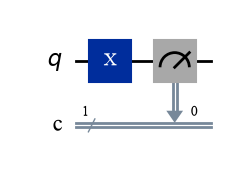

In [ ]:
measureCircuit1 = QuantumCircuit(1, 1)
measureCircuit1.x(0)           # first X: |0> -> |1>
measureCircuit1.measure(0, 0)  # then the measurement

measureBefore = QuantumCircuit(1, 1)  # reversed order quest 3
measureBefore.measure(0, 0)
measureBefore.x(0)

print("measureCircuit1:")
print(f"  qubits = {measureCircuit1.num_qubits}")
print(f"  clbits = {measureCircuit1.num_clbits}")
print(f"  gates  = {dict(measureCircuit1.count_ops())}")
print(f"  order  = {[instr.operation.name for instr in measureCircuit1.data]}")
print()
print(measureCircuit1.draw())
print("Measurement before X:")
print(measureBefore.draw())

measureCircuit1.draw("mpl")

### Responde

1. ¿Qué operación se aplica primero?
2. ¿Cómo se identifica el orden temporal?
3. ¿Qué ocurriría si la medida apareciese antes de $X$?
4. ¿El resultado clásico sería el mismo?

**Respuesta:**

1. Primero X, que pasa |0⟩ a |1⟩, y luego la medida, que da 1. Se ve en `order = ['x', 'measure']`.

2. En el dibujo el tiempo va de izquierda a derecha y la caja X está antes que el medidor. Coincide con el orden en que se añadieron las instrucciones.

3. Se mediría el qubit todavía en |0⟩, así que saldría 0. Después la X lo cambiaría a |1⟩, pero eso ya no llega al bit clásico porque no se vuelve a medir. Es el segundo dibujo de la celda.

4. No. Con X antes sale siempre 1 y con la medida antes siempre 0. Mismas operaciones, distinto orden, distinto resultado.

## Ejercicio 13. `measure_all()`

Crea dos qubits sin bits clásicos, aplica `measure_all()`, visualiza y consulta `num_clbits`.

clbits before measure_all() = 0
clbits after measure_all()  = 2
qubits                      = 2
registers                   = [ClassicalRegister(2, 'meas')]
operations                  = {'measure': 2, 'barrier': 1}

qubit -> clbit:
  q0 -> meas[0]
  q1 -> meas[1]

         ░ ┌─┐   
   q_0: ─░─┤M├───
         ░ └╥┘┌─┐
   q_1: ─░──╫─┤M├
         ░  ║ └╥┘
meas: 2/════╩══╩═
            0  1 


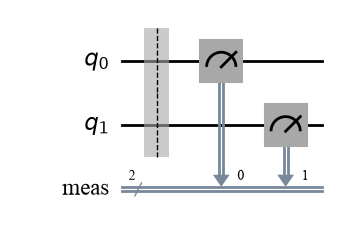

In [14]:
measureAllCircuit = QuantumCircuit(2)
clbitsBefore = measureAllCircuit.num_clbits

measureAllCircuit.measure_all()

print(f"clbits before measure_all() = {clbitsBefore}")
print(f"clbits after measure_all()  = {measureAllCircuit.num_clbits}")
print(f"qubits                      = {measureAllCircuit.num_qubits}")
print(f"registers                   = {measureAllCircuit.cregs}")
print(f"operations                  = {dict(measureAllCircuit.count_ops())}")
print()
print("qubit -> clbit:")
for instr in measureAllCircuit.data:
    if instr.operation.name == "measure":
        qubit = measureAllCircuit.find_bit(instr.qubits[0]).index
        clbit = measureAllCircuit.find_bit(instr.clbits[0]).index
        print(f"  q{qubit} -> meas[{clbit}]")
print()
print(measureAllCircuit.draw())

measureAllCircuit.draw("mpl")

### Responde

1. ¿Qué ha añadido `measure_all()`?
2. ¿Cuántos bits clásicos aparecen?
3. ¿Qué diferencia presenta respecto a `measure(0, 0)`?
4. ¿Cuándo conviene controlar explícitamente la correspondencia?

**Respuesta:**

1. Tres cosas: un registro clásico nuevo, `meas`, con un bit por qubit, una barrera y una medida por qubit que guarda qᵢ en meas[i]. Se ve en `operations = {'measure': 2, 'barrier': 1}`.

2. Dos, uno por qubit (`clbits` pasa de 0 a 2).

3. `measure(0, 0)` mide un solo qubit, necesita que el bit ya exista y tú eliges dónde se guarda. `measure_all()` mide todos, crea el registro solo, añade la barrera y fija qᵢ → meas[i] sin poder elegir.

4. Cuando solo quieres medir algunos qubits, cuando ya tienes registros clásicos, cuando necesitas un orden concreto de bits (ejercicio 28) o cuando mides a mitad de circuito. Ahí `measure_all()` puede dar bits de más o en otro orden.

# Parte E. Ejecución con Aer

## Ejercicio 14. Simulador y transpilación

Crea `AerSimulator()`. Transpila los circuitos de medida de $|0\rangle$ y $|1\rangle$ para ese backend y visualiza los resultados.

simulator = aer_simulator (AerSimulator)

|0>:
  gates original   = {'measure': 1}
  gates transpiled = {'measure': 1}
  depth            = 1 -> 1
  same object      = False
     ┌─┐
  q: ┤M├
     └╥┘
c: 1/═╩═
      0 

|1>:
  gates original   = {'x': 1, 'measure': 1}
  gates transpiled = {'x': 1, 'measure': 1}
  depth            = 2 -> 2
  same object      = False
     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 



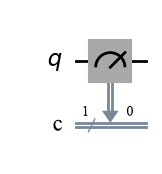

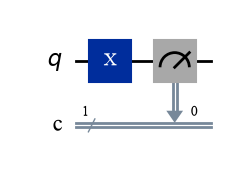

In [15]:
simulator = AerSimulator()

transpiled0 = transpile(measureCircuit0, simulator)
transpiled1 = transpile(measureCircuit1, simulator)

print(f"simulator = {simulator.name} ({type(simulator).__name__})")
print()

pairs = {"|0>": (measureCircuit0, transpiled0), "|1>": (measureCircuit1, transpiled1)}

for name, (original, transpiled) in pairs.items():
    print(f"{name}:")
    print(f"  gates original   = {dict(original.count_ops())}")
    print(f"  gates transpiled = {dict(transpiled.count_ops())}")
    print(f"  depth            = {original.depth()} -> {transpiled.depth()}")
    print(f"  same object      = {original is transpiled}")
    print(transpiled.draw())
    print()

display(transpiled0.draw("mpl"))
display(transpiled1.draw("mpl"))

### Responde

1. ¿El simulador es el circuito?
2. ¿Por qué se adapta un circuito al backend?
3. ¿Qué finalidad tendrá la transpilación en hardware real?
4. ¿Un simulador ideal incorpora automáticamente ruido?

**Respuesta:**

1. No. El circuito describe el experimento y el simulador es el backend que lo ejecuta. Un simulador puede ejecutar muchos circuitos y un circuito se puede ejecutar en varios backends.

2. Porque cada backend tiene sus limitaciones: puertas nativas, número de qubits y, en hardware real, qué qubits están conectados. Transpilar reescribe el circuito para cumplirlas sin cambiar lo que hace. Aquí `AerSimulator` acepta `x` y `measure` directamente, así que las puertas y la profundidad no cambian.

3. En hardware real descompone las puertas en las nativas, asigna los qubits del circuito a qubits físicos, añade SWAP cuando dos qubits no están conectados y optimiza para usar menos puertas. Es importante porque cada puerta añade error.

4. No. Por defecto `AerSimulator()` es ideal, sin errores. El ruido hay que añadirlo a mano, por ejemplo con un `NoiseModel`.

## Ejercicio 15. Ejecución de $|0\rangle$
Ejecuta 1.000 shots con `seed_simulator=42`. Recupera el trabajo, el resultado y los conteos. Comprueba la suma.

In [16]:
job0 = simulator.run(transpiled0, shots=1000, seed_simulator=SEED)
result0 = job0.result()
counts0 = result0.get_counts()

print("job0:")
print(f"  type    = {type(job0).__name__}")
print(f"  id      = {job0.job_id()}")
print(f"  status  = {job0.status()}")
print()
print("result0:")
print(f"  type    = {type(result0).__name__}")
print(f"  success = {result0.success}")
print(f"  backend = {result0.backend_name}")
print()
print(f"counts0     = {counts0} ({type(counts0).__name__})")
print(f"total       = {sum(counts0.values())}")
print(f"sum == 1000: {sum(counts0.values()) == 1000}")
print(f"all '0':     {counts0.get('0', 0) == 1000}")

job0:
  type    = AerJob
  id      = 7fc464ed-d8a5-45d8-a3d8-e89c79f0ebe8
  status  = JobStatus.DONE

result0:
  type    = Result
  success = True
  backend = aer_simulator

counts0     = {'0': 1000} (Counts)
total       = 1000
sum == 1000: True
all '0':     True


### Responde

1. ¿Qué representa el trabajo?
2. ¿Qué devuelve `result()`?
3. ¿Qué devuelve `get_counts()`?
4. ¿Cuánto suman los conteos?
5. ¿Por qué el resultado es determinista?

**Respuesta:**

1. Es la tarea que se ha mandado al backend con `run()` (un `AerJob`). No tiene los resultados directamente, sirve para seguir la ejecución (`job_id()`, `status()`) y recogerlos al final. En hardware real tiene sentido porque los trabajos hacen cola.

2. Un objeto `Result` con todo lo de la ejecución: si fue bien (`success = True`), el backend y los datos de cada circuito.

3. Un diccionario (`Counts`) con cada cadena de bits y cuántas veces salió. Aquí `{'0': 1000}`.

4. 1000, igual que los shots, porque cada shot da un único resultado.

5. Porque el qubit está en |0⟩, con P(0) = 1, así que sale 0 en los 1000 shots. No es por la semilla: la semilla solo hace reproducible el azar cuando hay superposición, aquí saldría lo mismo sin ella.

## Ejercicio 16. Ejecución de $|1\rangle$
Ejecuta 10, 100, 1.000 y 10.000 shots. Para cada caso calcula conteos y frecuencias.

In [17]:
shotsList = [10, 100, 1_000, 10_000]
deterministicResults = []

print(f"{'shots':>6} | {'counts':<14} | {'N(0)':>5} {'N(1)':>6} | {'f(0)':>5} {'f(1)':>5} | total ok")
print("-" * 65)

for s in shotsList:
    counts = simulator.run(transpiled1, shots=s, seed_simulator=SEED).result().get_counts()
    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    deterministicResults.append({"shots": s, "counts": counts, "N0": n0, "N1": n1, "f0": n0 / s, "f1": n1 / s})
    print(f"{s:>6} | {str(counts):<14} | {n0:>5} {n1:>6} | {n0 / s:>5.2f} {n1 / s:>5.2f} | {n0 + n1 == s}")

 shots | counts         |  N(0)   N(1) |  f(0)  f(1) | total ok
-----------------------------------------------------------------
    10 | {'1': 10}      |     0     10 |  0.00  1.00 | True
   100 | {'1': 100}     |     0    100 |  0.00  1.00 | True
  1000 | {'1': 1000}    |     0   1000 |  0.00  1.00 | True
 10000 | {'1': 10000}   |     0  10000 |  0.00  1.00 | True


### Responde

1. ¿Por qué conviene utilizar `get()`?
2. ¿Cambia la distribución al aumentar los shots?
3. ¿Aporta información nueva usar 10.000 shots en este caso?
4. ¿Aparece incertidumbre estadística en el simulador ideal?

**Respuesta:**

1. Porque `get_counts()` solo incluye lo que ha salido alguna vez. Aquí nunca sale 0, así que `counts["0"]` daría `KeyError`. Con `get("0", 0)` devuelve 0, que es justo lo que significa.

2. No. Con cualquier número de shots sale f(0) = 0 y f(1) = 1. Solo crecen los conteos.

3. No. El resultado es determinista, con 10 shots ya se tiene la distribución exacta. Más shots solo sirven cuando hay azar, como en superposición.

4. Aquí no, porque |1⟩ da siempre lo mismo y el simulador ideal no mete errores. Pero sí puede haberla en superposición: el azar viene de la propia medida cuántica, no del ruido. Lo vemos con |+⟩ en la Parte G.

# Parte F. Conteos e histogramas

## Ejercicio 17. Función de ejecución

Implementa una función que valide `shots`, transpile, ejecute y devuelva conteos.

In [ ]:
def runWithShots(circuit, shots=1000, seed=SEED):
    if not isinstance(circuit, QuantumCircuit):
        raise TypeError("The circuit must be a QuantumCircuit")

    if circuit.count_ops().get("measure", 0) == 0:  # does it have at least one measurement?
        raise ValueError("The circuit must contain at least one measurement")

    if isinstance(shots, bool) or not isinstance(shots, (int, np.integer)): 
        raise TypeError("shots must be an integer")

    if shots <= 0:
        raise ValueError("shots must be positive")

    backend = AerSimulator()
    transpiled = transpile(circuit, backend)
    return backend.run(transpiled, shots=shots, seed_simulator=seed).result().get_counts()


countsTest0 = runWithShots(measureCircuit0)
countsTest1 = runWithShots(measureCircuit1, shots=500)

print(f"|0> (1000 shots) = {countsTest0}")
print(f"|1> (500 shots)  = {countsTest1}")
print()

assert countsTest0 == {"0": 1000}
assert countsTest1 == {"1": 500}

invalidCases = {
    "zeroShots": ((measureCircuit0, 0), "shots = 0"),
    "negativeShots": ((measureCircuit0, -10), "shots < 0"),
    "floatShots": ((measureCircuit0, 10.5), "not an integer"),
    "boolShots": ((measureCircuit0, True), "bool is not a number of shots"),
    "noMeasurements": ((circuit1, 100), "circuit without measurements"),
    "notACircuit": (("not a circuit", 100), "not a QuantumCircuit"),
}

for name, ((circuit, shots), justification) in invalidCases.items():
    try:
        runWithShots(circuit, shots=shots)
        outcome = "NOT DETECTED"
    except (TypeError, ValueError) as error:
        outcome = type(error).__name__
    print(f"{name:15s} -> {outcome:12s} | {justification}")

|0> (1000 shots) = {'0': 1000}
|1> (500 shots)  = {'1': 500}

zeroShots       -> ValueError   | shots = 0
negativeShots   -> ValueError   | shots < 0
floatShots      -> TypeError    | not an integer
boolShots       -> TypeError    | bool is not a number of shots
noMeasurements  -> ValueError   | circuit without measurements
notACircuit     -> TypeError    | not a QuantumCircuit


## Ejercicio 18. Frecuencias

Implementa una función que convierta conteos en frecuencias y rechace diccionarios vacíos, conteos negativos, no enteros o con total cero.

In [19]:
def computeFrequencies(counts):
    if not isinstance(counts, dict):
        raise TypeError("The counts must be a dictionary")

    if len(counts) == 0:
        raise ValueError("The counts dictionary is empty")

    for outcome, count in counts.items():
        if isinstance(count, bool) or not isinstance(count, Integral):  # is it an integer?
            raise TypeError(f"The count of '{outcome}' is not an integer: {count!r}")
        if count < 0:  # is it non-negative?
            raise ValueError(f"The count of '{outcome}' is negative: {count}")

    total = sum(counts.values())
    if total == 0:
        raise ValueError("The total number of counts is zero")

    return {outcome: count / total for outcome, count in counts.items()}


exampleCounts = {"0": 250, "1": 750}
exampleFreqs = computeFrequencies(exampleCounts)

print(f"counts      = {exampleCounts}")
print(f"frequencies = {exampleFreqs}")
print(f"sum         = {sum(exampleFreqs.values())}")
print()
print(f"frequencies |0> = {computeFrequencies(counts0)}")
print(f"frequencies |1> = {computeFrequencies(countsTest1)}")
print()

assert np.isclose(exampleFreqs["0"], 0.25)
assert np.isclose(exampleFreqs["1"], 0.75)
assert np.isclose(sum(exampleFreqs.values()), 1.0)

invalidCases = {
    "emptyDict": ({}, "no outcomes"),
    "negativeCount": ({"0": -5, "1": 10}, "count < 0"),
    "floatCount": ({"0": 2.5, "1": 7}, "not an integer"),
    "boolCount": ({"0": True, "1": 3}, "bool is not a count"),
    "zeroTotal": ({"0": 0, "1": 0}, "total = 0"),
    "notADict": ([250, 750], "not a dictionary"),
}

for name, (counts, justification) in invalidCases.items():
    try:
        computeFrequencies(counts)
        outcome = "NOT DETECTED"
    except (TypeError, ValueError) as error:
        outcome = type(error).__name__
    print(f"{name:15s} -> {outcome:12s} | {justification}")

counts      = {'0': 250, '1': 750}
frequencies = {'0': 0.25, '1': 0.75}
sum         = 1.0

frequencies |0> = {'0': 1.0}
frequencies |1> = {'1': 1.0}

emptyDict       -> ValueError   | no outcomes
negativeCount   -> ValueError   | count < 0
floatCount      -> TypeError    | not an integer
boolCount       -> TypeError    | bool is not a count
zeroTotal       -> ValueError   | total = 0
notADict        -> TypeError    | not a dictionary


### Responde

1. ¿Qué diferencia existe entre conteo y frecuencia?
2. ¿Qué deben sumar las frecuencias?
3. ¿Equivale una frecuencia a una amplitud?
4. ¿Puede recuperarse el signo de una amplitud a partir de conteos?

**Respuesta:**

1. El conteo es cuántas veces sale un resultado y depende de los shots. La frecuencia es la proporción, f = N / shots, entre 0 y 1. Por ejemplo 250 de 1000 y 25 de 100 son conteos distintos pero la misma frecuencia, 0.25.

2. 1, porque cada shot da un resultado y los conteos suman el total de shots. En el ejemplo 0.25 + 0.75 = 1.

3. No. La amplitud es un complejo del vector de estado, la frecuencia es un real que estima la probabilidad, y la probabilidad es |α|². Hay dos pasos: la frecuencia solo aproxima la probabilidad y la probabilidad ya ha perdido la fase.

4. No. |α|² es igual para α y −α. Por ejemplo |+⟩ y |−⟩ dan casi los mismos conteos aunque el signo de la amplitud de |1⟩ cambie. Para verlo habría que aplicar H antes de medir.

## Ejercicio 19. Histogramas
Representa por separado los conteos de $|0\rangle$ y $|1\rangle$ y después ambos en una misma figura con leyenda.

counts0 = {'0': 1000}
counts1 = {'1': 1000}


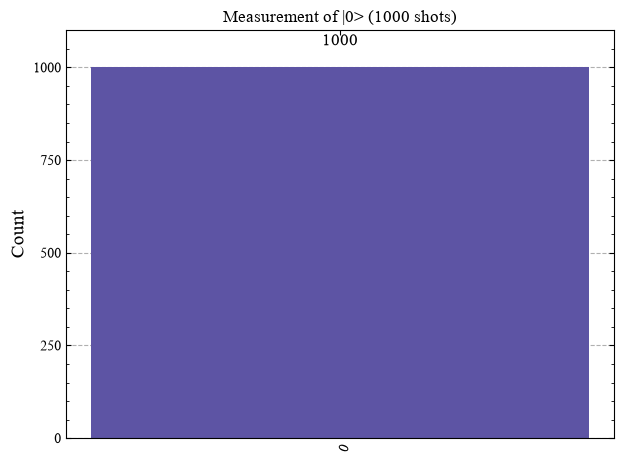

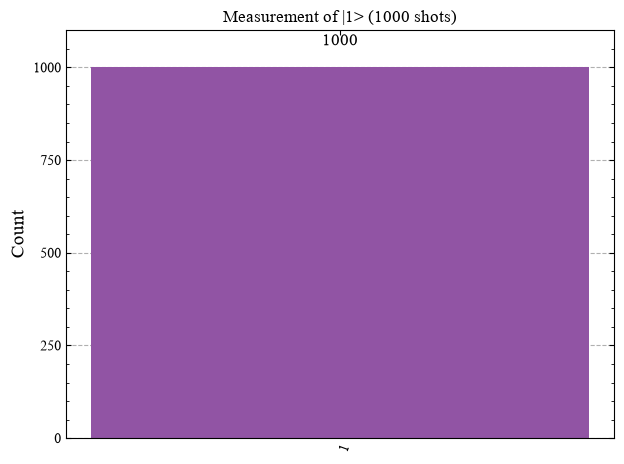

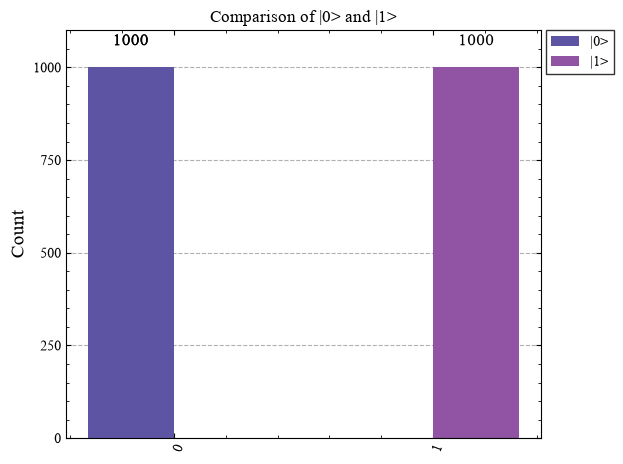

In [20]:
counts1 = runWithShots(measureCircuit1, shots=1000)  # in exercise 17 we used 500

print(f"counts0 = {counts0}")
print(f"counts1 = {counts1}")

display(plot_histogram(counts0, color=COLOR_TARGET, title="Measurement of |0> (1000 shots)"))
display(plot_histogram(counts1, color=COLOR_PRED, title="Measurement of |1> (1000 shots)"))
display(plot_histogram(
    [counts0, counts1],
    legend=["|0>", "|1>"],
    color=[COLOR_TARGET, COLOR_PRED],
    title="Comparison of |0> and |1>",
))

### Responde

1. ¿Qué información representa el histograma?
2. ¿Muestra el circuito o el vector de estado?
3. ¿Muestra amplitudes o fases?

**Respuesta:**

1. Los resultados de la ejecución: en el eje X las cadenas de bits y en el Y cuántas veces salió cada una. Es el diccionario de `get_counts()` en gráfico. Aquí cada histograma tiene una sola barra de 1000.

2. Ninguno. No muestra las puertas (eso es `draw()`) ni el estado (eso es `Statevector`), solo lo que sale al medir. El circuito vacío y el de XX darían el mismo histograma.

3. No. Solo conteos, que estiman |α|², y la fase se pierde al medir. X|0⟩ = |1⟩ e Y|0⟩ = i|1⟩ darían el mismo histograma.

# Parte G. Simulación exacta y muestreo

## Ejercicio 20. Primera superposición

Crea un circuito con una puerta $H$, obtén su vector y compáralo con $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$. Muestra probabilidades exactas.

   ┌───┐
q: ┤ H ├
   └───┘
HGate (Qiskit) =
[[ 0.70711+0.j  0.70711+0.j]
 [ 0.70711+0.j -0.70711+0.j]]

amplitudes Qiskit  = [0.70711+0.j 0.70711+0.j]
amplitudes NumPy   = [0.70711+0.j 0.70711+0.j]
equal              = True
norm               = 1.00000

P Qiskit           = [0.5 0.5]
P NumPy            = [0.5 0.5]
probabilities_dict = {'0': 0.5, '1': 0.5}
equal              = True


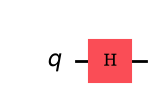

In [21]:
circuitPlus = QuantumCircuit(1)
circuitPlus.h(0)

statePlus = Statevector.from_instruction(circuitPlus)
ketPlus = (ket0 + ket1) / np.sqrt(2)
probsNumpy = np.abs(ketPlus) ** 2

print(circuitPlus.draw())
print("HGate (Qiskit) =")
print(Operator(HGate()).data)
print()
print(f"amplitudes Qiskit  = {statePlus.data}")
print(f"amplitudes NumPy   = {ketPlus}")
print(f"equal              = {np.allclose(statePlus.data, ketPlus)}")
print(f"norm               = {np.linalg.norm(statePlus.data):.5f}")
print()
print(f"P Qiskit           = {statePlus.probabilities()}")
print(f"P NumPy            = {probsNumpy}")
print(f"probabilities_dict = {probsDict(statePlus)}")
print(f"equal              = {np.allclose(statePlus.probabilities(), probsNumpy)}")

circuitPlus.draw("mpl")

## Ejercicio 21. Medida de la superposición

Crea una copia, añade medidas y ejecútala con 10, 100, 1.000 y 10.000 shots. Calcula $f(0)$, $f(1)$ y $|f(0)-1/2|$.

In [ ]:
circuitPlusMeasured = circuitPlus.copy()
circuitPlusMeasured.measure_all()

print(circuitPlusMeasured.draw())
print(f"circuitPlus still without measurements: {circuitPlus.count_ops().get('measure', 0) == 0}")
print()

superpositionResults = []

print(f"{'shots':>6} | {'counts':<22} | {'f(0)':>6} {'f(1)':>6} | {'|f(0)-1/2|':>10} | {'0.5/sqrt(N)':>11}")
print("-" * 76)

for s in shotsList:
    counts = runWithShots(circuitPlusMeasured, shots=s)
    freqs = computeFrequencies(counts)
    f0 = freqs.get("0", 0)
    f1 = freqs.get("1", 0)
    e0 = abs(f0 - 0.5)
    sigma = 0.5 / np.sqrt(s)
    superpositionResults.append({"shots": s, "counts": counts, "f0": f0, "f1": f1, "E0": e0, "sigma": sigma})
    print(f"{s:>6} | {str(counts):<22} | {f0:>6.4f} {f1:>6.4f} | {e0:>10.4f} | {sigma:>11.4f}")

        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 
circuitPlus still without measurements: True

 shots | counts                 |   f(0)   f(1) | |f(0)-1/2| | 0.5/sqrt(N)
----------------------------------------------------------------------------
    10 | {'1': 5, '0': 5}       | 0.5000 0.5000 |     0.0000 |      0.1581
   100 | {'1': 51, '0': 49}     | 0.4900 0.5100 |     0.0100 |      0.0500
  1000 | {'1': 486, '0': 514}   | 0.5140 0.4860 |     0.0140 |      0.0158
 10000 | {'0': 4921, '1': 5079} | 0.4921 0.5079 |     0.0079 |      0.0050


### Responde

1. ¿Coinciden exactamente frecuencias y probabilidades?
2. ¿Qué sucede normalmente al aumentar los shots?
3. ¿Debe disminuir estrictamente el error en cada fila?
4. ¿Qué diferencia hay respecto a $|0\rangle$ y $|1\rangle$?
5. ¿Se conserva la fase en los conteos?

**Respuesta:**

1. No. P(0) = P(1) = 0.5, pero las frecuencias fluctúan: con 1.000 shots sale f(0) = 0.514 y con 10.000, 0.4921. Solo coinciden por casualidad, como pasa aquí con 10 shots (5 y 5).

2. Las frecuencias se acercan a 0.5 por la ley de los grandes números. El error típico es 0.5/√N, así que para dividirlo entre 10 hacen falta 100 veces más shots.

3. No. Lo que baja es el error esperado, no el de cada ejecución. En la tabla el error sube de 0 (10 shots) a 0.01 (100) y a 0.014 (1.000). Hay que compararlo con 0.5/√N, que sí baja siempre. Con 10.000 shots el error, 0.0079, es algo mayor que 0.005, pero es normal (unas 1.6σ).

4. Con |0⟩ y |1⟩ el resultado es determinista y las frecuencias son iguales a las probabilidades con cualquier número de shots. Con |+⟩ cada shot es aleatorio y aparece error estadístico, aunque el simulador sea ideal.

5. No. Los conteos solo estiman |α|². |−⟩ tiene otra fase relativa y daría la misma distribución, mitad 0 y mitad 1.

## Ejercicio 22. Gráfica de convergencia

Representa shots frente a frecuencia de 0, con eje horizontal logarítmico y una línea teórica en 0,5. Interpreta la gráfica.

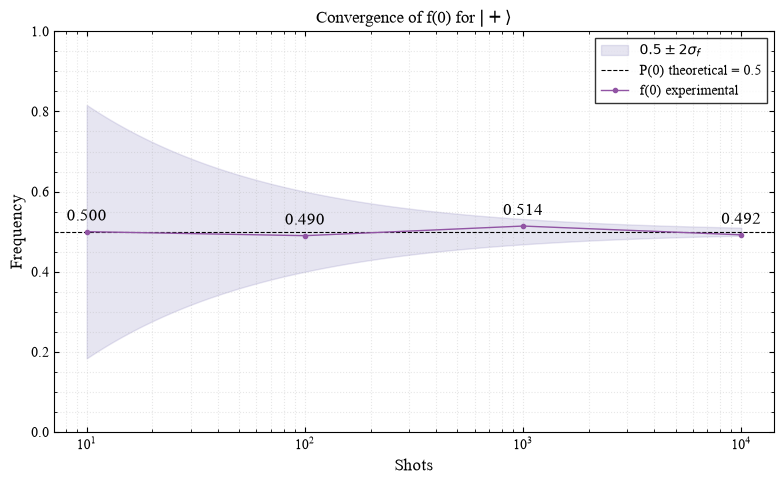

In [23]:
shotsPlot = np.array([r["shots"] for r in superpositionResults], dtype=float)
f0List = [r["f0"] for r in superpositionResults]

shotsSmooth = np.logspace(1, 4, 200)
sigmaSmooth = 0.5 / np.sqrt(shotsSmooth)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(shotsSmooth, 0.5 - 2 * sigmaSmooth, 0.5 + 2 * sigmaSmooth, color=COLOR_TARGET, alpha=0.15, label=r"$0.5 \pm 2\sigma_f$")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="P(0) theoretical = 0.5")
ax.plot(shotsPlot, f0List, "o-", color=COLOR_PRED, label="f(0) experimental")

for n, f in zip(shotsPlot, f0List):
    ax.annotate(f"{f:.3f}", (n, f), textcoords="offset points", xytext=(0, 8), ha="center")

ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("Shots")
ax.set_ylabel("Frequency")
ax.set_title(r"Convergence of f(0) for $|+\rangle$")
ax.legend(loc="best")
ax.grid(True, which="both", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación de la gráfica:**

Con 10 shots la frecuencia sale justo 0.5 (5 y 5), pero es casualidad. Con 100 baja a 0.49 y con 1.000 sube a 0.514. Con 10.000 se queda en 0.492, ya muy cerca de la línea teórica.

La banda es 0.5 ± 2σ_f, con σ_f = 0.5/√N, y se estrecha al aumentar los shots. Todos los puntos quedan dentro. La convergencia no es monótona: un punto con más shots no tiene por qué estar más cerca de 0.5 (el de 1.000 está más lejos que el de 100), pero sí dentro de una banda más estrecha. La escala logarítmica permite ver de 10 a 10.000 shots en la misma gráfica.

## Ejercicio 23. Comparación exacta y experimental

Con 10.000 shots, construye una tabla con resultado, amplitud, probabilidad exacta, conteo y frecuencia.

In [24]:
row10000 = next(r for r in superpositionResults if r["shots"] == 10_000)
counts10000 = row10000["counts"]
freqs10000 = computeFrequencies(counts10000)
probsPlus = statePlus.probabilities()

print(f"{'outcome':>7} | {'amplitude':>16} | {'P exact':>7} | {'N':>5} | {'f':>6} | {'|f - P|':>7}")
print("-" * 64)
for index, outcome in enumerate(["0", "1"]):
    amplitude = statePlus.data[index]
    p = probsPlus[index]
    n = counts10000.get(outcome, 0)
    f = freqs10000.get(outcome, 0)
    print(f"{outcome:>7} | {amplitude:>16.5f} | {p:>7.4f} | {n:>5} | {f:>6.4f} | {abs(f - p):>7.4f}")
print()
print(f"sum P = {probsPlus.sum():.5f}")
print(f"sum N = {sum(counts10000.values())}")
print(f"sum f = {sum(freqs10000.values()):.5f}")

outcome |        amplitude | P exact |     N |      f | |f - P|
----------------------------------------------------------------
      0 | 0.70711+0.00000j |  0.5000 |  4921 | 0.4921 |  0.0079
      1 | 0.70711+0.00000j |  0.5000 |  5079 | 0.5079 |  0.0079

sum P = 1.00000
sum N = 10000
sum f = 1.00000


### Responde

1. ¿Qué columnas proceden de `Statevector`?
2. ¿Cuáles requieren medida?
3. ¿Cuál conserva información de fase?
4. ¿Por qué los conteos no reconstruyen el estado completo?

**Respuesta:**

1. La amplitud y la probabilidad exacta. La amplitud es `statePlus.data` y la probabilidad `statePlus.probabilities()`. No hay shots ni azar.

2. El conteo y la frecuencia, que salen de ejecutar `circuitPlusMeasured` con 10.000 shots. Dependen de los shots y de la semilla: aquí 4921 y 5079, con un error de 0.0079.

3. Solo la amplitud, que es un complejo con módulo y fase. La probabilidad es |α|² y ya no la tiene, y los conteos tampoco.

4. Porque medir en la base computacional solo da |α|² y la fase se pierde (|+⟩ y |−⟩ dan los mismos conteos). Además con shots finitos solo hay una estimación, y cada medida colapsa el estado, así que hay que prepararlo otra vez en cada shot. Para reconstruirlo entero habría que medir en varias bases (tomografía).

# Parte H. Circuitos de dos qubits

## Ejercicio 24. Estado inicial

Crea dos qubits, obtén el vector y el diccionario de probabilidades, y comprueba que representan $|00\rangle$.

In [25]:
circuit00 = QuantumCircuit(2)
state00 = Statevector.from_instruction(circuit00)
ket00 = np.kron(ket0, ket0)  # |0> ⊗ |0>

print(f"state00.data  = {state00.data}")
print(f"amplitudes    = {len(state00.data)}")
print(f"dim           = {state00.dim}")
print(f"dims          = {state00.dims()}")
print(f"probabilities = {state00.probabilities()}")
print(f"probs dict    = {probsDict(state00)}")
print(f"equal to |0>⊗|0> (NumPy) = {np.allclose(state00.data, ket00)}")
print()
print(f"{'index':>5} | {'label':>6} | amplitude")
print("-" * 30)
for index, amplitude in enumerate(state00.data):
    print(f"{index:>5} | {'|' + format(index, '02b') + '>':>6} | {amplitude:.3f}")
print()

state000 = Statevector.from_instruction(QuantumCircuit(3))
print(f"dim with 3 qubits = {state000.dim}")

state00.data  = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
amplitudes    = 4
dim           = 4
dims          = (2, 2)
probabilities = [1. 0. 0. 0.]
probs dict    = {'00': 1.0}
equal to |0>⊗|0> (NumPy) = True

index |  label | amplitude
------------------------------
    0 |   |00> | 1.000+0.000j
    1 |   |01> | 0.000+0.000j
    2 |   |10> | 0.000+0.000j
    3 |   |11> | 0.000+0.000j

dim with 3 qubits = 8


### Responde

1. ¿Cuántas amplitudes contiene?
2. ¿Por qué son cuatro?
3. ¿Cuál es el orden de la base?
4. ¿Qué dimensión tendrá un estado de tres qubits?

**Respuesta:**

1. Cuatro: (1, 0, 0, 0). La de |00⟩ es 1 y el resto 0, así que P(00) = 1.

2. Porque el espacio de dos qubits es ℂ² ⊗ ℂ² = ℂ⁴ (una amplitud por cada combinación de valores), 2 × 2 = 4. Por eso `state00` coincide con `np.kron(ket0, ket0)`.

3. |00⟩, |01⟩, |10⟩, |11⟩: el índice k es k en binario. Qiskit es *little-endian*, las etiquetas se leen |q1 q0⟩ con q0 a la derecha. El índice 1 es |01⟩, o sea q0 = 1 y q1 = 0.

4. 2³ = 8, como sale en la celda. En general 2ⁿ, crece exponencialmente, y por eso simular muchos qubits en un ordenador clásico se vuelve imposible: con 50 qubits harían falta unos 10¹⁵ números complejos.

## Ejercicio 25. Base computacional de dos qubits
Construye circuitos para $|00\rangle$, $|01\rangle$, $|10\rangle$ y $|11\rangle$. Dibuja cada uno y muestra su vector y `probabilities_dict()`.

|00>:
  gates          = {}
  vector         = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
  probs dict     = {'00': 1.0}
  equal to NumPy = True


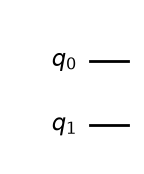

|01>:
  gates          = {'x': 1}
  vector         = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
  probs dict     = {'01': 1.0}
  equal to NumPy = True


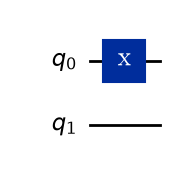

|10>:
  gates          = {'x': 1}
  vector         = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
  probs dict     = {'10': 1.0}
  equal to NumPy = True


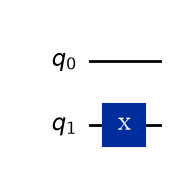

|11>:
  gates          = {'x': 2}
  vector         = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
  probs dict     = {'11': 1.0}
  equal to NumPy = True


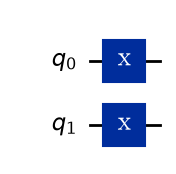

state | X on   | index | q1 q0 |   P | label ok
--------------------------------------------------
 |00> | []     |     0 |  0  0 | 1.0 | True
 |01> | [0]    |     1 |  0  1 | 1.0 | True
 |10> | [1]    |     2 |  1  0 | 1.0 | True
 |11> | [0, 1] |     3 |  1  1 | 1.0 | True


In [26]:
circuit01 = QuantumCircuit(2)
circuit01.x(0)  # |01>: q0 = 1

circuit10 = QuantumCircuit(2)
circuit10.x(1)  # |10>: q1 = 1

circuit11 = QuantumCircuit(2)
circuit11.x(0)
circuit11.x(1)

basisCircuits = {"|00>": circuit00, "|01>": circuit01, "|10>": circuit10, "|11>": circuit11}

# Qiskit labels are |q1 q0>, so in NumPy: |q1> ⊗ |q0>
basisKets = {
    "|00>": np.kron(ket0, ket0),
    "|01>": np.kron(ket0, ket1),
    "|10>": np.kron(ket1, ket0),
    "|11>": np.kron(ket1, ket1),
}

basisStates = {}
for name, circuit in basisCircuits.items():
    state = Statevector.from_instruction(circuit)
    basisStates[name] = state
    print(f"{name}:")
    print(f"  gates          = {dict(circuit.count_ops())}")
    print(f"  vector         = {state.data}")
    print(f"  probs dict     = {probsDict(state)}")
    print(f"  equal to NumPy = {np.allclose(state.data, basisKets[name])}")
    display(circuit.draw("mpl"))

print(f"{'state':>5} | {'X on':<6} | {'index':>5} | {'q1':>2} {'q0':>2} | {'P':>3} | label ok")
print("-" * 50)
for name, state in basisStates.items():
    circuit = basisCircuits[name]
    xQubits = [circuit.find_bit(instr.qubits[0]).index for instr in circuit.data]
    index = int(np.argmax(np.abs(state.data)))
    label = f"{index:02b}"
    p = state.probabilities()[index]
    labelOk = list(probsDict(state)) == [name[1:3]]
    print(f"{name:>5} | {str(xQubits):<6} | {index:>5} | {label[0]:>2} {label[1]:>2} | {p:>3.1f} | {labelOk}")

## Ejercicio 26. Orden de bits

Aplica `x(0)` a dos qubits. Muestra el vector y el diccionario de probabilidades.

vector     = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
probs dict = {'01': 1.0}
P(q0)      = [0. 1.]
P(q1)      = [1. 0.]

index | |q1 q0> | q1 q0 | amplitude
------------------------------------
    0 |    |00> |  0  0 | 0.000+0.000j
    1 |    |01> |  0  1 | 1.000+0.000j
    2 |    |10> |  1  0 | 0.000+0.000j
    3 |    |11> |  1  1 | 0.000+0.000j

equal to |01> (ex. 25)   = True
equal to |10> (ex. 25)   = False
equal to |0>⊗|1> (NumPy) = True
with x(1) instead        = {'10': 1.0}


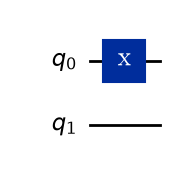

In [27]:
circuitOrder = QuantumCircuit(2)
circuitOrder.x(0)  # X only on q0

stateOrder = Statevector.from_instruction(circuitOrder)

circuitOrderQ1 = QuantumCircuit(2)  # counterexample: X on q1
circuitOrderQ1.x(1)

print(f"vector     = {stateOrder.data}")
print(f"probs dict = {probsDict(stateOrder)}")
print(f"P(q0)      = {stateOrder.probabilities([0])}")
print(f"P(q1)      = {stateOrder.probabilities([1])}")
print()
print(f"{'index':>5} | {'|q1 q0>':>7} | {'q1':>2} {'q0':>2} | amplitude")
print("-" * 36)
for index, amplitude in enumerate(stateOrder.data):
    label = f"{index:02b}"
    print(f"{index:>5} | {'|' + label + '>':>7} | {label[0]:>2} {label[1]:>2} | {amplitude:.3f}")
print()
print(f"equal to |01> (ex. 25)   = {stateOrder == basisStates['|01>']}")
print(f"equal to |10> (ex. 25)   = {stateOrder == basisStates['|10>']}")
print(f"equal to |0>⊗|1> (NumPy) = {np.allclose(stateOrder.data, np.kron(ket0, ket1))}")
print(f"with x(1) instead        = {probsDict(Statevector.from_instruction(circuitOrderQ1))}")

circuitOrder.draw("mpl")

### Responde

1. ¿Por qué aparece `"01"` y no `"10"`?
2. ¿Qué valores tienen $q_0$ y $q_1$?
3. ¿En qué orden se muestran las cadenas?
4. ¿Cuál es el orden del vector de amplitudes?

**Respuesta:**

1. Porque Qiskit es *little-endian*: q0 va a la derecha de la cadena, que se lee |q1 q0⟩. `x(0)` pone q0 = 1 y deja q1 = 0, así que sale "01". "10" sería q1 = 1, que es lo que da `x(1)`, como se ve en la última línea de la celda.

2. q0 = 1 y q1 = 0. Las probabilidades marginales lo confirman: `P(q0) = [0. 1.]` y `P(q1) = [1. 0.]`. Es |0⟩ ⊗ |1⟩ = |01⟩, igual que en NumPy y en el ejercicio 25.

3. Con el qubit de mayor índice a la izquierda y q0 a la derecha, como los números en binario. Así cada cadena es un número k = q0·2⁰ + q1·2¹ + ... Ojo, en muchos libros (como Nielsen y Chuang) es al revés, q0 a la izquierda.

4. Por índice k = 0, 1, ..., 2ⁿ − 1: |00⟩, |01⟩, |10⟩, |11⟩. Aquí el vector es (0, 1, 0, 0) y la amplitud no nula está en el índice 1, que es "01". El orden del vector y el de las cadenas coinciden.

## Ejercicio 27. Medida de dos qubits

Para los cuatro estados de la base, crea copias con dos bits clásicos, mide cada qubit en el bit del mismo índice y ejecuta 1.000 shots.

|00>: counts = {'00': 1000}


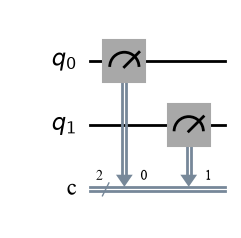

|01>: counts = {'01': 1000}


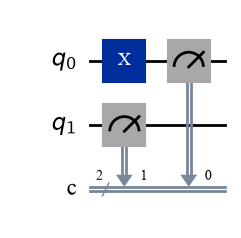

|10>: counts = {'10': 1000}


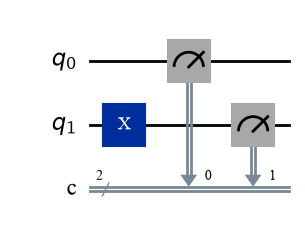

|11>: counts = {'11': 1000}


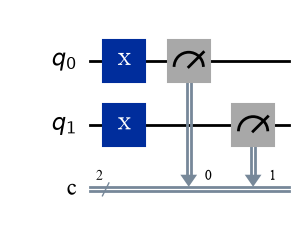

state | counts         | total | expected | ok
-------------------------------------------------
 |00> | {'00': 1000}   |  1000 |       00 | True
 |01> | {'01': 1000}   |  1000 |       01 | True
 |10> | {'10': 1000}   |  1000 |       10 | True
 |11> | {'11': 1000}   |  1000 |       11 | True

originals without measurements: True
originals without clbits:       True


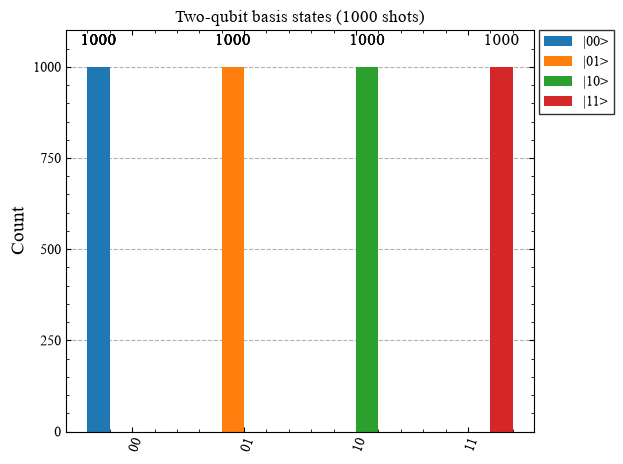

In [28]:
basisCounts = {}
basisMeasureCircuits = {}

for name, circuit in basisCircuits.items():
    measured = QuantumCircuit(2, 2)  # new circuit with 2 clbits, the original stays untouched
    measured.compose(circuit, inplace=True)
    measured.measure(0, 0)  # q0 -> c0
    measured.measure(1, 1)  # q1 -> c1

    basisMeasureCircuits[name] = measured
    basisCounts[name] = runWithShots(measured, shots=1000)

    print(f"{name}: counts = {basisCounts[name]}")
    display(measured.draw("mpl"))

print(f"{'state':>5} | {'counts':<14} | {'total':>5} | {'expected':>8} | ok")
print("-" * 49)
for name, counts in basisCounts.items():
    expected = name[1:3]
    ok = counts == {expected: 1000}
    print(f"{name:>5} | {str(counts):<14} | {sum(counts.values()):>5} | {expected:>8} | {ok}")
print()
print(f"originals without measurements: {all(c.count_ops().get('measure', 0) == 0 for c in basisCircuits.values())}")
print(f"originals without clbits:       {all(c.num_clbits == 0 for c in basisCircuits.values())}")

display(plot_histogram(
    list(basisCounts.values()),
    legend=list(basisCounts.keys()),
    title="Two-qubit basis states (1000 shots)",
))

## Ejercicio 28. Intercambio de bits clásicos
Prepara $|01\rangle$ y compara la medida directa `q0→c0, q1→c1` con la medida intercambiada `q0→c1, q1→c0`.

direct:
  mapping      = q0 -> c0, q1 -> c1
  state before = {'01': 1.0}
  counts       = {'01': 1000}


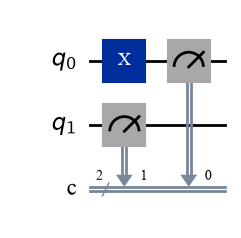

swapped:
  mapping      = q0 -> c1, q1 -> c0
  state before = {'01': 1.0}
  counts       = {'10': 1000}


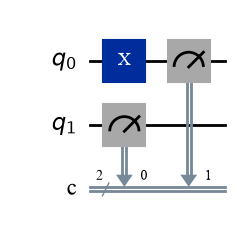

same state before measuring: True
same classical string:       False
swapped == direct reversed:  True


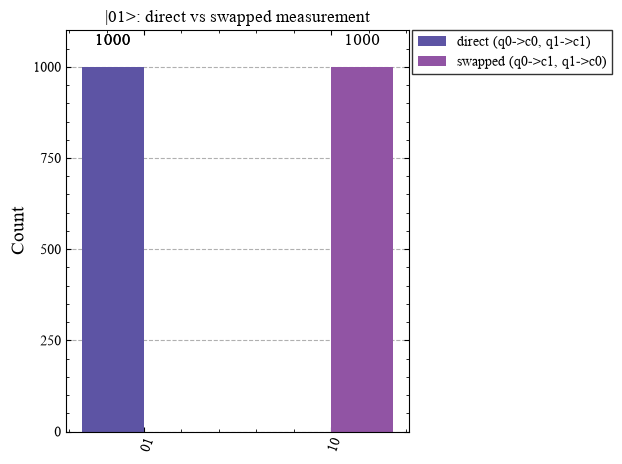

In [29]:
directCircuit = QuantumCircuit(2, 2)
directCircuit.compose(circuit01, inplace=True)
directCircuit.measure(0, 0)  # q0 -> c0
directCircuit.measure(1, 1)  # q1 -> c1

swappedCircuit = QuantumCircuit(2, 2)
swappedCircuit.compose(circuit01, inplace=True)
swappedCircuit.measure(0, 1)  # q0 -> c1
swappedCircuit.measure(1, 0)  # q1 -> c0

mappingCircuits = {"direct": directCircuit, "swapped": swappedCircuit}
mappingCounts = {}
statesBefore = {}

for name, circuit in mappingCircuits.items():
    mapping = [
        (circuit.find_bit(instr.qubits[0]).index, circuit.find_bit(instr.clbits[0]).index)
        for instr in circuit.data if instr.operation.name == "measure"
    ]
    statesBefore[name] = Statevector.from_instruction(circuit.remove_final_measurements(inplace=False))
    mappingCounts[name] = runWithShots(circuit, shots=1000)

    print(f"{name}:")
    print(f"  mapping      = {', '.join(f'q{q} -> c{c}' for q, c in mapping)}")
    print(f"  state before = {probsDict(statesBefore[name])}")
    print(f"  counts       = {mappingCounts[name]}")
    display(circuit.draw("mpl"))

reversedDirect = {bits[::-1]: n for bits, n in mappingCounts["direct"].items()}

print(f"same state before measuring: {statesBefore['direct'] == statesBefore['swapped']}")
print(f"same classical string:       {mappingCounts['direct'] == mappingCounts['swapped']}")
print(f"swapped == direct reversed:  {mappingCounts['swapped'] == reversedDirect}")

display(plot_histogram(
    [mappingCounts["direct"], mappingCounts["swapped"]],
    legend=["direct (q0->c0, q1->c1)", "swapped (q0->c1, q1->c0)"],
    color=[COLOR_TARGET, COLOR_PRED],
    title="|01>: direct vs swapped measurement",
))

### Responde

1. ¿Cambia el estado anterior a la medida?
2. ¿Cambia la cadena clásica?
3. ¿Qué demuestra el experimento?
4. ¿Por qué debe revisarse el mapeo entre qubits y bits?

**Respuesta:**

1. No. Los dos circuitos aplican la misma X sobre q0, así que antes de medir el estado es |01⟩ en ambos (`same state before measuring: True`). El mapeo solo decide dónde se guarda cada resultado.

2. Sí. La directa da "01" y la intercambiada "10". Los qubits valen lo mismo (q0 = 1, q1 = 0), pero la cadena se escribe con los bits clásicos, c1 c0. Al intercambiar, el 1 de q0 va a c1 y la cadena sale al revés (`swapped == direct reversed: True`).

3. Que la cadena describe los bits clásicos, no los qubits directamente. El mismo estado puede dar cadenas distintas según cómo se mida, así que para interpretar un resultado hay que saber en qué bit se guardó cada qubit.

4. Porque un mapeo mal hecho da resultados que parecen correctos pero se interpretan mal. Aquí alguien pensaría que el estado era |10⟩ cuando era |01⟩, y no sale ningún error ni aviso. Es importante cuando el resultado codifica un número en binario, porque al invertir los bits sale otro número.

# Parte I. Interpretación conceptual

## Ejercicio 29. Clasificación

Clasifica y justifica: `QuantumCircuit(2,2)`, `Statevector.from_instruction(c)`, `estado.data`, `estado.probabilities()`, `measure()`, `"01"`, `{"00":492,"11":508}`, `492/1000`, `plot_histogram()` y `simulador.run()`.

**Respuesta:**

- `QuantumCircuit(2,2)`: construcción. Crea un circuito con 2 qubits y 2 bits clásicos. Solo describe el experimento, no ejecuta nada.

- `Statevector.from_instruction(c)`: simulación exacta. Calcula el estado final de `c` multiplicando matrices, sin shots ni azar. No admite circuitos con medidas.

- `estado.data`: amplitudes. Array de NumPy con las 2ⁿ amplitudes complejas. Es lo único de la lista que conserva la fase.

- `estado.probabilities()`: probabilidades exactas. Es |α|² de cada resultado por la regla de Born, incluidos los ceros. Ya no tienen fase.

- `measure()`: instrucción de medida (construcción). Añade una medida al circuito, pero no mide nada hasta que se ejecuta. No es una puerta unitaria, es irreversible.

- `"01"`: resultado de un shot. Cadena de bits clásicos leída como c1 c0. Es la clave con la que se agrupan los conteos.

- `{"00":492,"11":508}`: conteos (experimental). Es lo que devuelve `get_counts()` y suma 1000 shots. Que solo salgan 00 y 11, cerca de 500 cada uno, cuadra con un estado tipo Bell, con P(00) = P(11) = 0.5.

- `492/1000`: frecuencia (experimental). f(00) = 0.492, que estima P(00) = 0.5. La diferencia, 0.008, es menor que 0.5/√1000 ≈ 0.016, así que es una fluctuación normal.

- `plot_histogram()`: visualización. Dibuja los conteos como barras. No muestra ni el circuito ni el estado, ni amplitudes ni fases.

- `simulador.run()`: ejecución. Manda el circuito al backend, que lo repite los shots indicados y muestrea las medidas. Devuelve un trabajo, del que luego se sacan `result()` y `get_counts()`.

En resumen: se construye (`QuantumCircuit`, `measure()`), se calcula exacto (`Statevector`, `data`, `probabilities()`), se ejecuta (`run()`), se obtienen resultados experimentales (`"01"`, los conteos, `492/1000`) y se visualizan (`plot_histogram()`). Por el camino se pierde información: la amplitud tiene fase, la probabilidad no, y los conteos solo la estiman.

## Ejercicio 30. Verdadero o falso

Justifica:

1. Crear un circuito lo ejecuta inmediatamente.
2. Los qubits comienzan por defecto en $|0\rangle$.
3. Un bit clásico puede contener una superposición.
4. Declarar bits clásicos añade medidas.
5. `Statevector.data` contiene amplitudes.
6. `probabilities_dict()` devuelve conteos.
7. Cada shot incluye una nueva preparación.
8. El histograma muestra amplitudes.
9. La transpilación adapta el circuito al backend.
10. Dos circuitos distintos pueden producir el mismo estado final.
11. Probabilidades iguales implican amplitudes iguales.
12. Qiskit muestra $q_0$ a la izquierda de las cadenas.
13. `x(0)` sobre dos qubits prepara $|01\rangle$.
14. Un simulador ideal incluye ruido automáticamente.
15. La medida puede eliminar información de fase.

**Respuesta:**

1. Falso. Crear un circuito solo genera un objeto que lo describe. No pasa nada hasta que se calcula con `Statevector` o se ejecuta con `run()`.

2. Verdadero. Todos empiezan en |0⟩: `state0` sale (1, 0) y `state00` sale (1, 0, 0, 0).

3. Falso. Un bit clásico vale 0 o 1, la superposición es solo de los qubits.

4. Falso. Solo reserva sitio. Hay que añadir `measure()` o `measure_all()`, y en el ejercicio 3 `operations` salía 0.

5. Verdadero. Es un array `complex128` con las 2ⁿ amplitudes.

6. Falso. Devuelve probabilidades exactas, sin shots. Los conteos salen de `get_counts()` y son enteros.

7. Verdadero. La medida colapsa el estado, así que en cada shot se vuelve a preparar desde |0...0⟩, se aplica el circuito y se mide.

8. Falso. Muestra conteos, que estiman |α|². Ni amplitudes ni fase.

9. Verdadero. Lo reescribe con las puertas y restricciones del backend sin cambiar lo que hace.

10. Verdadero. `circuit0` y `circuitXX` son distintos, pero los dos dan |0⟩ porque X² = I.

11. Falso. |+⟩ y |−⟩ tienen las mismas probabilidades (0.5 y 0.5), pero la amplitud de |1⟩ es 1/√2 en uno y −1/√2 en el otro.

12. Falso. Qiskit pone q0 a la derecha, las cadenas se leen qₙ₋₁...q1 q0.

13. Verdadero. `x(0)` pone q0 = 1 y deja q1 = 0, y como q0 va a la derecha sale |01⟩ (ejercicio 26).

14. Falso. `AerSimulator()` es ideal por defecto, el ruido hay que añadirlo con un `NoiseModel`.

15. Verdadero. Medir en la base computacional solo da |α|² y la fase se pierde: |+⟩ y |−⟩ dan los mismos conteos. Para verla hay que aplicar una puerta antes de medir, como H.

# Reto avanzado. Analizador de circuitos

Implementa una función que reciba un circuito sin medidas y devuelva el vector, probabilidades exactas, una copia con medidas, conteos y frecuencias. Debe validar el tipo, los shots y que el circuito no contenga medidas.

In [30]:
def analyzeCircuit(circuit, shots=1000, seed=SEED):
    if not isinstance(circuit, QuantumCircuit):
        raise TypeError("The circuit must be a QuantumCircuit")

    if isinstance(shots, bool) or not isinstance(shots, (int, np.integer)):  # bool is a subclass of int
        raise TypeError("shots must be an integer")

    if shots <= 0:
        raise ValueError("shots must be positive")

    if circuit.count_ops().get("measure", 0) > 0:  # does it already contain measurements?
        raise ValueError("The circuit must not contain measurements")

    state = Statevector.from_instruction(circuit)  # exact part

    measured = circuit.copy()  # the original is not modified
    measured.measure_all()

    counts = runWithShots(measured, shots=shots, seed=seed)  # sampled part

    return {
        "state": state,
        "amplitudes": state.data,
        "probabilities": state.probabilities_dict(),
        "measuredCircuit": measured,
        "counts": counts,
        "frequencies": computeFrequencies(counts),
    }


challengeCircuits = {"empty": circuit0, "X": circuit1, "XX": circuitXX, "H": circuitPlus, "|01>": circuitOrder}
previousStates = {"empty": state0, "X": state1, "XX": stateXX, "H": statePlus, "|01>": stateOrder}
before = {name: (dict(c.count_ops()), c.num_clbits) for name, c in challengeCircuits.items()}

analyses = {name: analyzeCircuit(c) for name, c in challengeCircuits.items()}

for name, a in analyses.items():
    print(f"{name}:")
    print(f"  amplitudes    = {a['amplitudes']}")
    print(f"  probabilities = {probsDict(a['state'])}")
    print(f"  counts        = {a['counts']}")
    print(f"  frequencies   = {a['frequencies']}")
    print()

print(f"{'circuit':>7} | {'outcome':>7} | {'P':>6} | {'N':>5} | {'f':>6} | {'|f - P|':>7}")
print("-" * 54)
for name, a in analyses.items():
    for outcome in sorted(set(a["probabilities"]) | set(a["counts"])):
        p = a["probabilities"].get(outcome, 0)
        n = a["counts"].get(outcome, 0)
        f = a["frequencies"].get(outcome, 0)
        print(f"{name:>7} | {outcome:>7} | {p:>6.4f} | {n:>5} | {f:>6.4f} | {abs(f - p):>7.4f}")

for name, a in analyses.items():
    assert sum(a["counts"].values()) == 1000                                # counts add up to shots
    assert np.isclose(sum(a["frequencies"].values()), 1.0)                  # frequencies add up to 1
    assert np.allclose(a["amplitudes"], previousStates[name].data)          # same state as before
    assert all(a["probabilities"].get(o, 0) > 0 for o in a["counts"])       # observed outcomes are possible
    circuit = challengeCircuits[name]
    assert (dict(circuit.count_ops()), circuit.num_clbits) == before[name]  # original untouched

for name in ["empty", "X", "XX", "|01>"]:  # deterministic: f == P exactly
    a = analyses[name]
    assert all(np.isclose(a["frequencies"].get(o, 0), p) for o, p in a["probabilities"].items())

assert abs(analyses["H"]["frequencies"].get("0", 0) - 0.5) < 3 * 0.5 / np.sqrt(1000)  # within 3 sigma

print()
print("All checks passed")
print()

invalidCases = {
    "notACircuit": (("not a circuit", 1000), "not a QuantumCircuit"),
    "zeroShots": ((circuit1, 0), "shots = 0"),
    "negativeShots": ((circuit1, -10), "shots < 0"),
    "floatShots": ((circuit1, 10.5), "not an integer"),
    "boolShots": ((circuit1, True), "bool is not a number of shots"),
    "withMeasures": ((measureCircuit1, 1000), "circuit already measured"),
}

for name, ((circuit, shots), justification) in invalidCases.items():
    try:
        analyzeCircuit(circuit, shots=shots)
        outcome = "NOT DETECTED"
    except (TypeError, ValueError) as error:
        outcome = type(error).__name__
    print(f"{name:15s} -> {outcome:12s} | {justification}")

empty:
  amplitudes    = [1.+0.j 0.+0.j]
  probabilities = {'0': 1.0}
  counts        = {'0': 1000}
  frequencies   = {'0': 1.0}

X:
  amplitudes    = [0.+0.j 1.+0.j]
  probabilities = {'1': 1.0}
  counts        = {'1': 1000}
  frequencies   = {'1': 1.0}

XX:
  amplitudes    = [1.+0.j 0.+0.j]
  probabilities = {'0': 1.0}
  counts        = {'0': 1000}
  frequencies   = {'0': 1.0}

H:
  amplitudes    = [0.70711+0.j 0.70711+0.j]
  probabilities = {'0': 0.5, '1': 0.5}
  counts        = {'1': 486, '0': 514}
  frequencies   = {'1': 0.486, '0': 0.514}

|01>:
  amplitudes    = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
  probabilities = {'01': 1.0}
  counts        = {'01': 1000}
  frequencies   = {'01': 1.0}

circuit | outcome |      P |     N |      f | |f - P|
------------------------------------------------------
  empty |       0 | 1.0000 |  1000 | 1.0000 |  0.0000
      X |       1 | 1.0000 |  1000 | 1.0000 |  0.0000
     XX |       0 | 1.0000 |  1000 | 1.0000 |  0.0000
      H |       0 | 0.5000 |   

### Responde

1. ¿Qué parte es exacta?
2. ¿Qué parte depende de los shots?
3. ¿Qué información desaparece en los conteos?
4. ¿Por qué se conserva el circuito original sin medidas?
5. ¿Cómo comprobarías la coherencia entre conteos y shots?

**Respuesta:**

1. El vector de estado y las probabilidades exactas, que salen de `Statevector.from_instruction()` sin medir ni shots. Siempre dan lo mismo y coinciden con los estados de los ejercicios anteriores (lo comprueban los `assert`).

2. Los conteos y las frecuencias, que salen de ejecutar la copia con medidas. En los deterministas (vacío, X, XX y |01⟩) coinciden con las probabilidades, pero con H fluctúan alrededor de 0.5: aquí salen 514 y 486, con un error de 0.014.

3. Las amplitudes y su fase. Los conteos solo estiman |α|², y encima con error de muestreo.

4. Porque `Statevector` no acepta circuitos con medidas, así que el original es el que permite el cálculo exacto. Además la función no debe cambiar lo que recibe: los objetos se pasan por referencia, y si añadiéramos las medidas al original quedaría modificado fuera de la función y la siguiente llamada fallaría. Por eso se trabaja sobre una copia, y las pruebas comprueban que los originales no cambian.

5. Comprobando que los conteos suman exactamente los shots, porque cada shot da un resultado. También que las frecuencias suman 1, que todo resultado que sale tiene probabilidad mayor que 0 y que |f − P| es del orden de √(P(1 − P)/N). En las pruebas uso 3σ como margen.

# Pruebas mínimas

Descomenta estas pruebas al completar la práctica y añade casos inválidos.

In [31]:
def raises(errorType, func, *args, **kwargs):
    try:
        func(*args, **kwargs)
        return False

    except errorType:
        return True

# Provided tests
assert circuit0.num_qubits == 1
assert circuit0.num_clbits == 0
assert np.allclose(state0.data, [1, 0])
assert np.allclose(state1.data, [0, 1])
assert np.allclose(stateXX.data, [1, 0])
assert np.allclose(xMatrix @ ket0, state1.data)
assert sum(counts0.values()) == 1000
assert counts0.get("0", 0) == 1000
assert np.allclose(statePlus.probabilities(), [0.5, 0.5])

# Frequencies
freqsTest = computeFrequencies({"0": 250, "1": 750})
assert np.isclose(freqsTest["0"], 0.25)
assert np.isclose(freqsTest["1"], 0.75)
assert np.isclose(sum(freqsTest.values()), 1.0)
assert computeFrequencies(counts0) == {"0": 1.0}
assert all(np.isclose(r["f0"] + r["f1"], 1.0) for r in superpositionResults)
assert superpositionResults[-1]["E0"] < 3 * superpositionResults[-1]["sigma"]  # 10.000 shots within 3 sigma

# Two qubits
assert np.allclose(state00.data, [1, 0, 0, 0])
assert state000.dim == 8
for name, vector in [("|00>", [1, 0, 0, 0]), ("|01>", [0, 1, 0, 0]), ("|10>", [0, 0, 1, 0]), ("|11>", [0, 0, 0, 1])]:
    assert np.allclose(basisStates[name].data, vector)
    assert basisCounts[name] == {name[1:3]: 1000}
assert np.allclose(stateOrder.probabilities([0]), [0, 1])  # q0 = 1
assert np.allclose(stateOrder.probabilities([1]), [1, 0])  # q1 = 0
assert mappingCounts["direct"] == {"01": 1000}
assert mappingCounts["swapped"] == {"10": 1000}

# Invalid shots and circuits
for func, circuit in [(runWithShots, measureCircuit0), (analyzeCircuit, circuit1)]:
    assert raises(ValueError, func, circuit, shots=0)           # zero
    assert raises(ValueError, func, circuit, shots=-10)         # negative
    assert raises(TypeError, func, circuit, shots=10.5)         # not an integer
    assert raises(TypeError, func, circuit, shots=True)         # bool
    assert raises(TypeError, func, "not a circuit", shots=100)  # not a circuit
assert raises(ValueError, runWithShots, circuit1)               # no measurements
assert raises(ValueError, analyzeCircuit, measureCircuit1)      # already measured

# Invalid counts
assert raises(ValueError, computeFrequencies, {})                  # empty
assert raises(ValueError, computeFrequencies, {"0": -5, "1": 10})  # negative
assert raises(TypeError, computeFrequencies, {"0": 2.5, "1": 7})   # not an integer
assert raises(TypeError, computeFrequencies, {"0": True, "1": 3})  # bool
assert raises(ValueError, computeFrequencies, {"0": 0, "1": 0})    # total zero
assert raises(TypeError, computeFrequencies, [250, 750])           # not a dict

# The original circuit is preserved
testCircuit = QuantumCircuit(2)
testCircuit.h(0)
testCircuit.x(1)
gatesBefore = dict(testCircuit.count_ops())
testAnalysis = analyzeCircuit(testCircuit, shots=100)

assert dict(testCircuit.count_ops()) == gatesBefore
assert testCircuit.num_clbits == 0
assert testAnalysis["measuredCircuit"] is not testCircuit
assert testAnalysis["measuredCircuit"].count_ops().get("measure", 0) == 2
assert circuitPlus.count_ops().get("measure", 0) == 0          # exercise 21 used a copy
assert all(c.num_clbits == 0 for c in basisCircuits.values())  # exercise 27 used new circuits

print("All tests passed")

All tests passed
